# Objective of this analysis is to answer "What drives housing prices in California?"

### import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("housing.csv")

### Understand the dataset

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### Handling missing values

<Axes: >

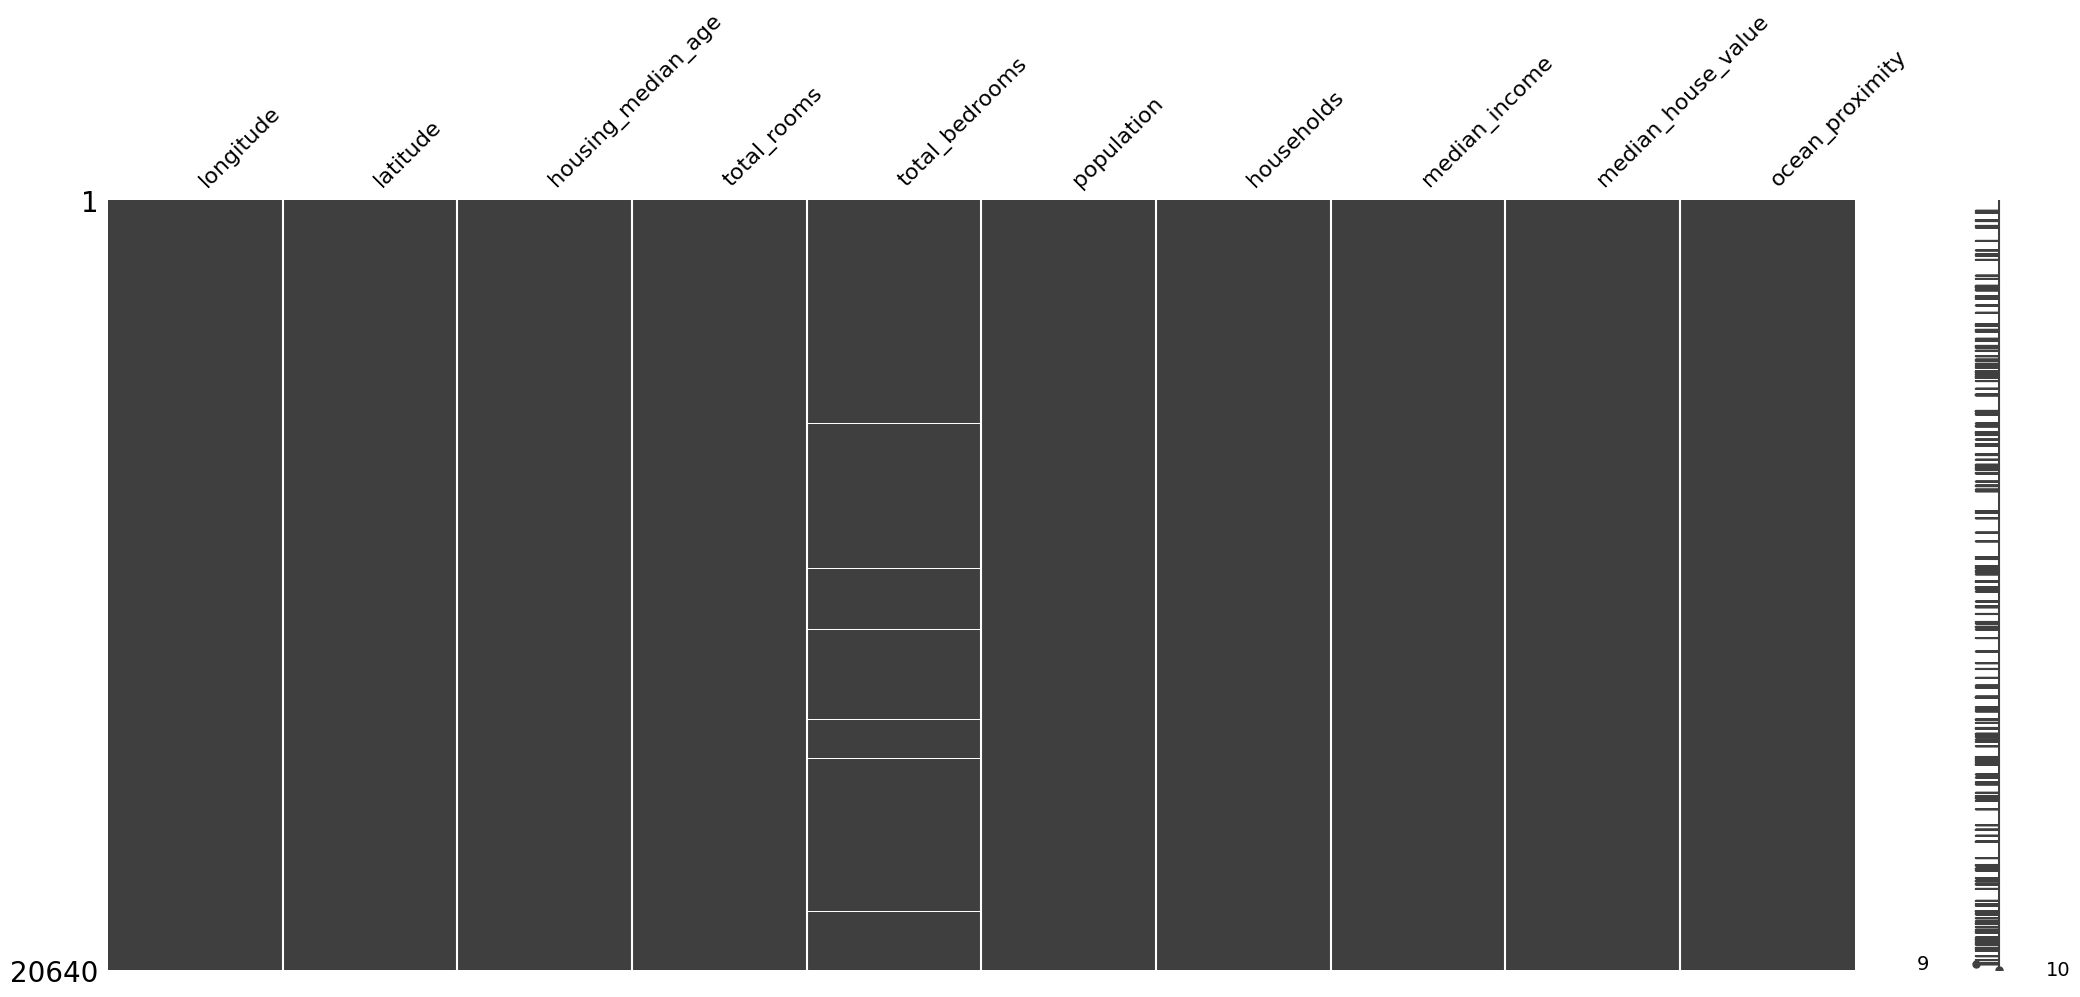

In [5]:
msno.matrix(df)

In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### There is only missing value in total_bedrooms.We can't drop all 207 rows rather we can fill them with median value. But for that we need to chech a few things at first

In [7]:
df['ocean_proximity'].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [8]:
df.groupby("ocean_proximity")["total_bedrooms"].median()

ocean_proximity
<1H OCEAN     438.0
INLAND        423.0
ISLAND        512.0
NEAR BAY      423.0
NEAR OCEAN    464.0
Name: total_bedrooms, dtype: float64

In [9]:
df['total_bedrooms'] = df.groupby('ocean_proximity')['total_bedrooms'].transform(
    lambda x: x.fillna(x.median())
)

# Univariate Analysis

### Before jumping to correlations or models, an analyst first understands each variable individually. This is called univariate analysis.

# About your target variable median_house_value:
    What does the distribution look like — is it spread out or concentrated?
    Is it skewed? Remember the max was capped at $500,001
    Where do most house values cluster?

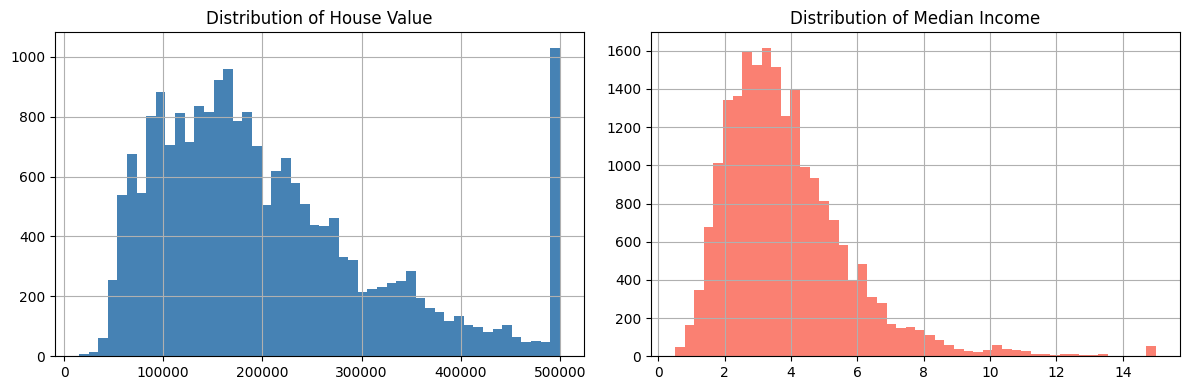

In [11]:
# Let's visualize the distribution at first
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['median_house_value'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of House Value')

df['median_income'].hist(bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Median Income')

plt.tight_layout()
plt.show()